In [2]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# Predicting Freight Cost

**Objective:** Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

- Freight is a non-trivial component of landed cost.
- Poor freight estimates distort margin and inventory planning.
- Automating freight estimation helps procurement teams forecast true cost before invoice arrival.

In [3]:
conn = sqlite3.connect('/Users/varunxsensei/Desktop/Project/Freight Cost Prediction/data/inventory.db')

In [7]:
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [8]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [10]:
for table in tables['name']:
    print("Table name", table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [11]:
vendor_df = pd.read_sql_query("select * from vendor_invoice",conn)

In [14]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [29]:
vendor_df[['Quantity',	'Dollars'	,'Freight']].corr(numeric_only = True)

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


<Axes: >

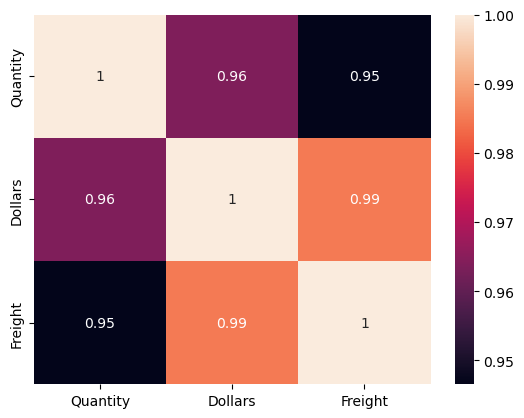

In [31]:
sns.heatmap(vendor_df[['Quantity',	'Dollars'	,'Freight']].corr(numeric_only = True),annot = True)

<Axes: xlabel='Quantity', ylabel='Freight'>

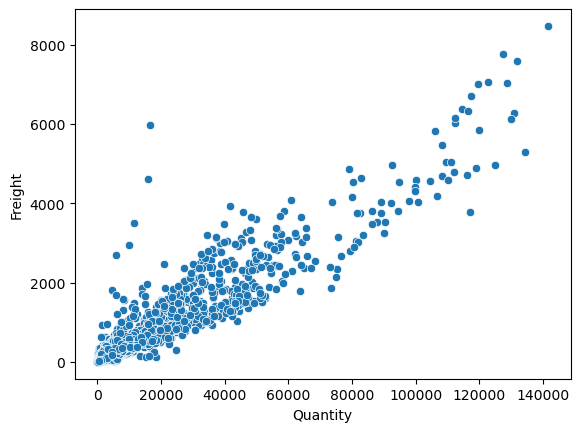

In [32]:
sns.scatterplot(data = vendor_df,x = 'Quantity',y = 'Freight')

<Axes: xlabel='Dollars', ylabel='Freight'>

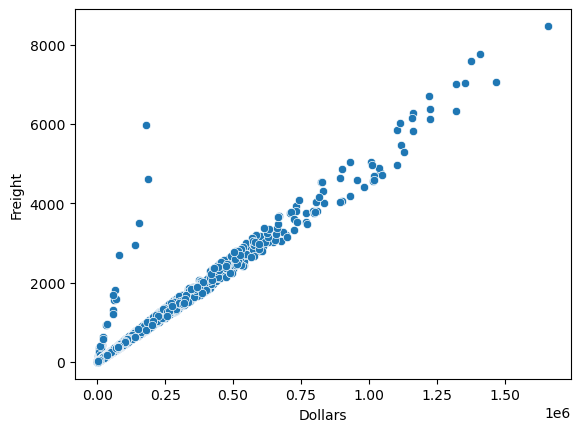

In [34]:
sns.scatterplot(data=vendor_df,x = 'Dollars',y = 'Freight')

In [35]:
vendor_df.sample(3)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
5135,90047,CRUSH WINES,2024-12-16,13295,2024-11-30,2025-01-29,318,2937.45,14.39,None
1919,2242,DELICATO VINEYARDS INC,2024-05-21,10055,2024-05-03,2024-06-20,2237,19048.63,97.15,None
3881,7240,"PREMIUM PORT WINES, INC.",2024-09-23,11946,2024-09-04,2024-10-24,167,1174.57,5.52,None


In [36]:
vendor_df['Freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']

In [38]:
vendor_df.sample(3)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_per_unit
4425,90011,FORTUNE WINE BROKERS LLC,2024-10-24,12522,2024-10-09,2024-12-10,101,838.72,4.36,None,0.043168
3679,8004,SAZERAC CO INC,2024-09-12,11827,2024-08-26,2024-10-15,34618,207108.42,994.12,None,0.028717
2401,8892,TRINCHERO FAMILY ESTATES,2024-06-14,10493,2024-06-01,2024-07-14,6748,43251.79,198.96,None,0.029484


In [39]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [44]:
vendor_df[vendor_df['Quantity'] < low_quantity]['Freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [45]:
vendor_df[vendor_df['Quantity'] > high_quantity]['Freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [46]:
X = vendor_df[['Quantity','Dollars']]

In [47]:
X

,Quantity,Dollars
0,6,214.26
1,15,140.55
2,5,106.60
3,10100,137483.78
4,1935,15527.25
...,...,...
5538,90,1563.00
5539,4617,37300.48
5540,9848,202815.78
5541,24747,149007.56


In [50]:
y = vendor_df['Freight']

In [53]:
vendor_df.describe().round()
#this tells we have outliers

,VendorNumber,PONumber,Quantity,Dollars,Freight,Freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error

In [57]:
model1 = LinearRegression()
model1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
model2 = DecisionTreeRegressor(max_depth = 4,random_state=42)
model2.fit(X_train,y_train)
model3 = RandomForestRegressor(max_depth = 4,random_state = 42)
model3.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
def evaluate_model(model,X_test,y_test,name):
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = root_mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)*100

    print(f"\n{name} performance")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"r2_score : {r2:.2f}%")
    
    

In [80]:
evaluate_model(model1,X_test,y_test,"LinearRegression")
evaluate_model(model2,X_test,y_test,"DecisionTreeRegressor")
evaluate_model(model3,X_test,y_test,"RandomForestRegressor")


LinearRegression performance
MAE : 24.46
RMSE : 124.43
r2_score : 97.00%

DecisionTreeRegressor performance
MAE : 38.12
RMSE : 138.25
r2_score : 96.30%

RandomForestRegressor performance
MAE : 30.26
RMSE : 130.56
r2_score : 96.70%


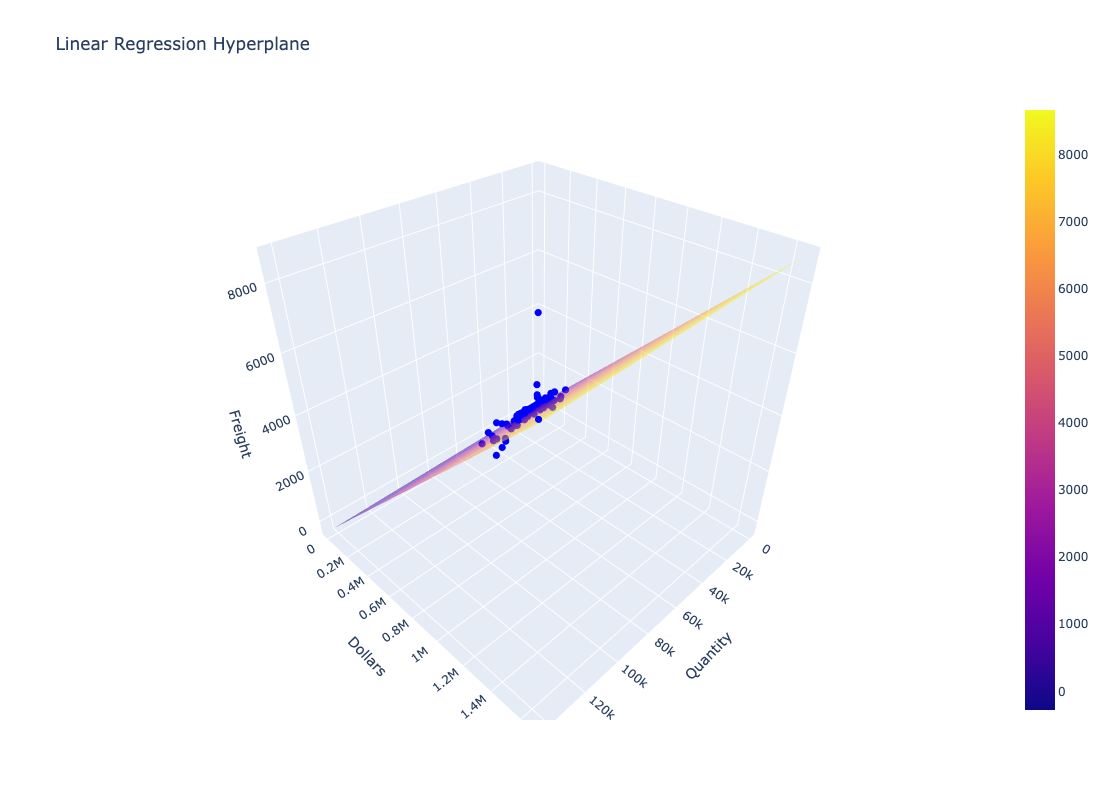

In [89]:
import numpy as np
import plotly.graph_objects as go

# Features
x1 = X_test.iloc[:, 0]
x2 = X_test.iloc[:, 1]
y = y_test

# Create meshgrid for regression plane
x1_grid = np.linspace(x1.min(), x1.max(), 50)
x2_grid = np.linspace(x2.min(), x2.max(), 50)

X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

# Plane equation
Y_grid = (
    model1.intercept_
    + model1.coef_[0] * X1_grid
    + model1.coef_[1] * X2_grid
)

# Scatter points
scatter = go.Scatter3d(
    x=x1,
    y=x2,
    z=y,
    mode='markers',
    marker=dict(
        size=4,
        color='blue'
    ),
    name='Actual Data'
)

# Regression plane
surface = go.Surface(
    x=X1_grid,
    y=X2_grid,
    z=Y_grid,
    opacity=0.5,
    name='Regression Plane'
)

fig = go.Figure(data=[surface, scatter])

fig.update_layout(
    title='Linear Regression Hyperplane',
    scene=dict(
        xaxis_title=X_test.columns[0],
        yaxis_title=X_test.columns[1],
        zaxis_title='Freight'
    ),
    width=1000,
    height=800
)

fig.show()